In [2]:
import yfinance as yf
import pandas as pd

# Define assets and timeframe
assets = ['TSLA', 'BND', 'SPY']
start_date = '2015-01-01'
end_date = '2025-01-01'

# 1. Download data with auto_adjust=True
# This makes 'Close' the same as 'Adjusted Close'
data = yf.download(assets, start=start_date, end=end_date, auto_adjust=True)

# 2. Extract only the 'Close' prices
# For multiple assets, 'data' is a MultiIndex. data['Close'] gives us 
# a DataFrame where columns are the Tickers.
df = data['Close']

# 3. Clean column names (optional but helpful)
df.columns.name = None 

print("Data successfully loaded!")
print(df.head())

[*********************100%***********************]  3 of 3 completed

Data successfully loaded!
                  BND         SPY       TSLA
Date                                        
2015-01-02  59.405441  169.687851  14.620667
2015-01-05  59.577896  166.623337  14.006000
2015-01-06  59.750381  165.053909  14.085333
2015-01-07  59.786362  167.110672  14.063333
2015-01-08  59.692871  170.076065  14.041333


In [3]:
# Check for missing values
print("Missing values:\n", df.isnull().sum())

# Handle missing values (Forward fill)
df = df.ffill()

# Basic Statistics
print("\nSummary Statistics:\n", df.describe())

Missing values:
 BND     0
SPY     0
TSLA    0
dtype: int64

Summary Statistics:
                BND          SPY         TSLA
count  2516.000000  2516.000000  2516.000000
mean     65.764829   308.672945   115.679423
std       4.562421   113.881824   114.226440
min      58.729237   154.161621     9.578000
25%      62.222515   211.051239    17.185167
50%      64.784897   271.769928    28.505667
75%      69.202244   397.220413   220.205002
max      74.832924   595.575012   479.859985


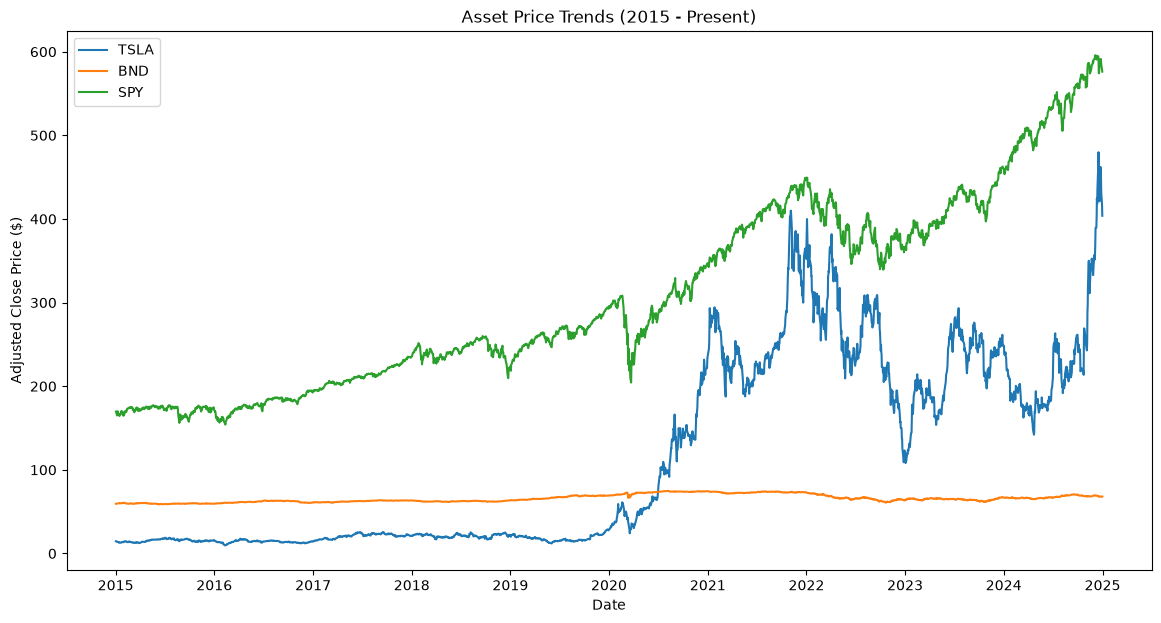

In [4]:
plt.figure(figsize=(14, 7))
for asset in assets:
    plt.plot(df[asset], label=asset)
plt.title('Asset Price Trends (2015 - Present)')
plt.xlabel('Date')
plt.ylabel('Adjusted Close Price ($)')
plt.legend()
plt.show()

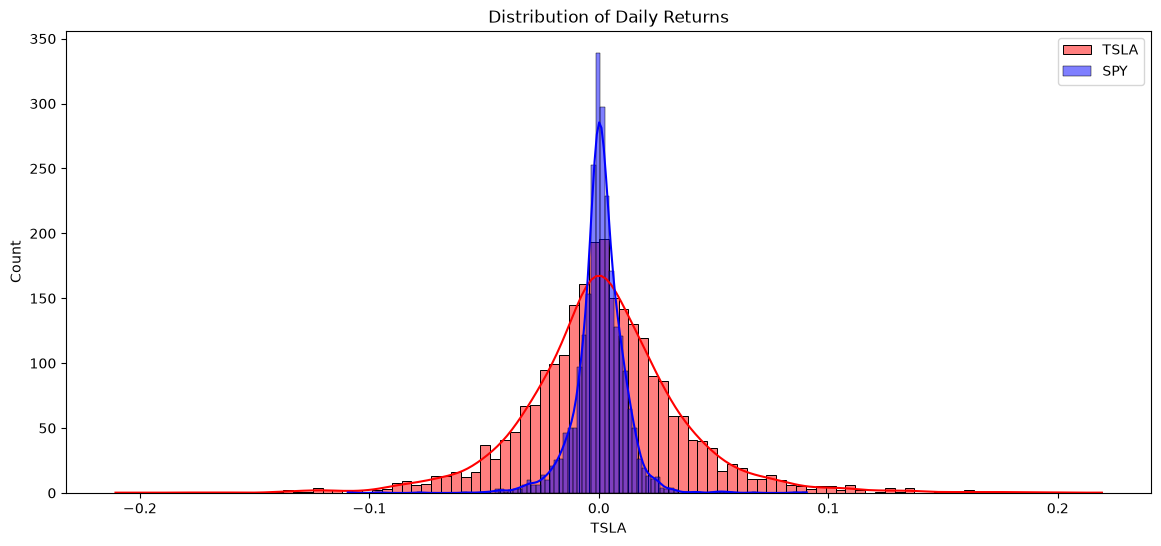

In [5]:
# Calculate daily percentage change
returns = df.pct_change().dropna()

plt.figure(figsize=(14, 6))
sns.histplot(returns['TSLA'], kde=True, color='red', label='TSLA', bins=100)
sns.histplot(returns['SPY'], kde=True, color='blue', label='SPY', bins=100)
plt.title('Distribution of Daily Returns')
plt.legend()
plt.show()

In [6]:
def check_stationarity(timeseries):
    print(f'--- ADF Test for {timeseries.name} ---')
    result = adfuller(timeseries)
    print(f'ADF Statistic: {result[0]}')
    print(f'p-value: {result[1]}')
    if result[1] <= 0.05:
        print("Result: Stationary (Reject Null Hypothesis)")
    else:
        print("Result: Non-Stationary (Fail to Reject Null)")

# Test on Close Price (usually non-stationary)
check_stationarity(df['TSLA'])

# Test on Returns (usually stationary)
check_stationarity(returns['TSLA'])

--- ADF Test for TSLA ---
ADF Statistic: -0.5814025136000573
p-value: 0.8751291675208068
Result: Non-Stationary (Fail to Reject Null)
--- ADF Test for TSLA ---
ADF Statistic: -50.14287777547797
p-value: 0.0
Result: Stationary (Reject Null Hypothesis)


In [7]:
# Annualized Sharpe Ratio (Assuming 252 trading days and 0% risk-free rate)
sharpe_ratio = (returns.mean() / returns.std()) * np.sqrt(252)
print("Annualized Sharpe Ratios:\n", sharpe_ratio)

Annualized Sharpe Ratios:
 BND     0.277199
SPY     0.783864
TSLA    0.866605
dtype: float64


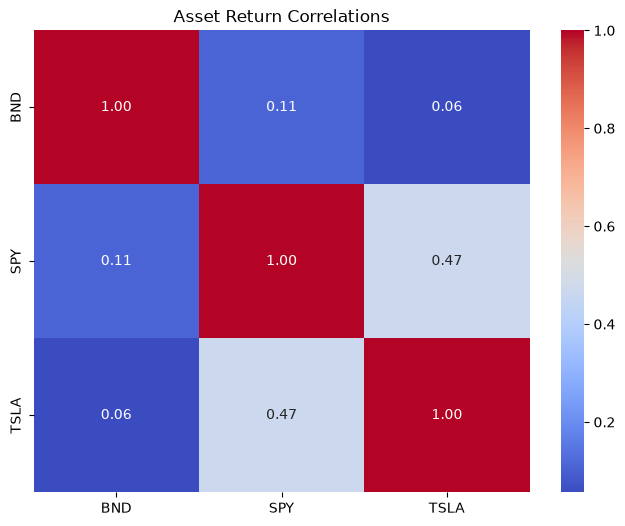

In [8]:
# Correlation Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(returns.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Asset Return Correlations')
plt.show()